# Week 12 - Milestone Two week

# 1. Lesson: no lesson this week.  Milestone Two is due!

# 2. Weekly graph question

Suppose you plot the number visitors to a museum over the seven days of a week; then again the following week.  Can you suggest the advantages and disadvantages of the following two ways of presenting the data?

In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Text(0, 0.5, 'Number of visitors')

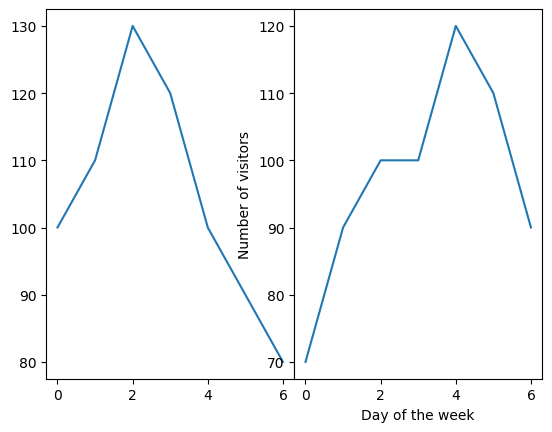

In [5]:
np.random.seed(0)
time_series_0 = np.array([100, 110, 130, 120, 100, 90, 80])
time_series_1 = np.array([70, 90, 100, 100, 120, 110, 90])
fig, axs = plt.subplots(1, 2)
axs[0].plot(time_series_0)
axs[1].plot(time_series_1)
plt.subplots_adjust(wspace = 0)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

Text(0, 0.5, 'Number of visitors')

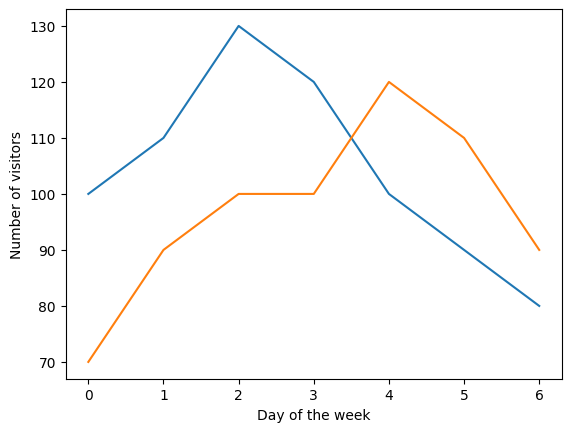

In [6]:
plt.plot(time_series_0)
plt.plot(time_series_1)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

# 3. Working on your datasets

This week, you can work on Milestone Two rather than having a particular exercise about working on your datasets

In [7]:
df = pd.read_csv("./cleaned_datasets/cleaned_risk_factors.csv")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           835 non-null    float64
 2   First sexual intercourse            835 non-null    float64
 3   Num of pregnancies                  835 non-null    float64
 4   Smokes                              835 non-null    float64
 5   Smokes (years)                      835 non-null    float64
 6   Smokes (packs/year)                 835 non-null    float64
 7   Hormonal Contraceptives             835 non-null    float64
 8   Hormonal Contraceptives (years)     835 non-null    float64
 9   IUD                                 835 non-null    float64
 10  IUD (years)                         835 non-null    float64
 11  STDs                                835 non-n

In [15]:
df.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy,z-score
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,...,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,8.350000e+02
mean,27.023952,2.565269,17.020320,2.302313,0.149572,1.253319,0.465626,0.650368,2.297180,0.114425,...,0.089820,0.021557,0.010778,0.021557,0.028743,0.041916,0.087425,0.051497,0.064671,2.489027e-16
std,8.482986,1.653132,2.805154,1.406110,0.354138,4.108331,2.238620,0.446378,3.552201,0.296810,...,0.306335,0.145319,0.103320,0.145319,0.167182,0.200518,0.282626,0.221142,0.246091,1.000599e+00
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.398602e-01
25%,21.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.339394e-01
50%,26.000000,2.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.339394e-01
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.719815e-01
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,37.000000,1.000000,30.000000,1.000000,...,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.542000e+01


In [16]:
X = df.drop(columns=['Biopsy', 'z-score', 'STD_Status', 'Partner_Group', 'First_Intercourse_Group', 'Schiller', 'Citology', 'Hinselmann'], axis=1)
y = df['Biopsy']

In [44]:
X.shape

(835, 30)

In [18]:
from sklearn.model_selection import train_test_split

random_seed = 42

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size = 0.2, random_state = random_seed)

In [19]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

# Implement Random Forest model
rfc = RandomForestClassifier(random_state=random_seed, n_jobs=-2, class_weight="balanced_subsample")
rfc.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', n_jobs=-2,
                       random_state=42)

In [20]:
import warnings

warnings.filterwarnings("ignore", module="sklearn")

In [27]:
from scipy.stats import randint

skfold = StratifiedKFold(n_splits=5, random_state=random_seed, shuffle=True)


# Tune Hyperparameters using RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(50, 250, 20),  # Adjusted for larger datasets
    'max_depth': [None, 2, 5, 10, 20, 30],  # Added deeper trees for complex data
    'min_samples_split': randint(3, 12, 3),  # Standard values for splitting
    'min_samples_leaf': [1, 2, 4],  # Added leaf size for regularization
    'max_leaf_nodes': [None, 20, 50, 100],  # More options for leaf nodes
    'criterion': ['gini']  # Evaluate both splitting criteria
}
random_search = RandomizedSearchCV(estimator=rfc, param_distributions=param_distributions, cv=skfold, n_iter=30, random_state=random_seed, n_jobs=-1, scoring='recall')
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Precision:", random_search.best_score_)

results_df = pd.DataFrame(random_search.cv_results_)

Best Parameters: {'criterion': 'gini', 'max_depth': 2, 'max_leaf_nodes': None, 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 161}
Best Cross-Validation Precision: 0.4583333333333333


In [28]:
# Sort the models by their mean test score (Precision) in descending order
top_10_models = results_df.sort_values(by='mean_test_score', ascending=False).head(10)

# Select only the most relevant columns so the output isn't overwhelmingly wide
columns_to_show = ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']

print("Top 10 Hyperparameter Combinations:")
# Setting max_colwidth allows the dictionary of parameters to print fully
with pd.option_context('display.max_colwidth', None): 
    print(top_10_models[columns_to_show])

Top 10 Hyperparameter Combinations:
    rank_test_score  mean_test_score  std_test_score  \
23                1         0.458333        0.117195   
14                1         0.458333        0.117195   
10                1         0.458333        0.117195   
15                4         0.433333        0.088889   
20                5         0.408333        0.109573   
21                6         0.386111        0.111250   
25                7         0.363889        0.082589   
2                 8         0.341667        0.072222   
17                9         0.319444        0.086958   
13                9         0.319444        0.086958   

                                                                                                                                params  
23  {'criterion': 'gini', 'max_depth': 2, 'max_leaf_nodes': None, 'min_samples_leaf': 4, 'min_samples_split': 12, 'n_estimators': 131}  
14    {'criterion': 'gini', 'max_depth': 2, 'max_leaf_nodes': 100, 'min_s

In [25]:
from sklearn.model_selection import GridSearchCV

# Targeted Grid Search based on cervical cancer Randomized Search results
param_grid = {
    'n_estimators': [100, 150, 260],      # Captures the low, mid, and high winning clusters
    'max_depth': [10, 20, None],          # Shifted to shallower trees based on top 10
    'max_leaf_nodes': [50, 100, None],    # Brought back to capture the top 2 winning configurations
    'min_samples_split': [6, 8, 10],      # Shifted lower to catch the 6, 7, and 8 sweet spots
    'min_samples_leaf': [1, 2],           # Perfect as is
    'criterion': ['gini']                 # Gini swept the top 10
}

grid_search = GridSearchCV(
    estimator=rfc, 
    param_grid=param_grid, 
    cv=skfold, 
    scoring='recall',  # Changed to recall to focus on minimizing false negatives
    n_jobs=-2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Recall:", grid_search.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'max_leaf_nodes': 50, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best Cross-Validation Recall: 0.3194444444444445


In [26]:
# Load the results dictionary into a pandas DataFrame
grid_results_df = pd.DataFrame(grid_search.cv_results_)

# Sort the models by their mean test score (Precision) in descending order
top_10_grid = grid_results_df.sort_values(by='mean_test_score', ascending=False).head(10)

# Select only the most relevant columns so the output is readable
columns_to_show = ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']

print("Top 10 Grid Search Models by Precision:")
print("-" * 60)

# Setting max_colwidth allows the dictionary of parameters to print fully
with pd.option_context('display.max_colwidth', None): 
    print(top_10_grid[columns_to_show])

Top 10 Grid Search Models by Precision:
------------------------------------------------------------
     rank_test_score  mean_test_score  std_test_score  \
141                1         0.319444        0.086958   
87                 1         0.319444        0.086958   
69                 1         0.319444        0.086958   
123                1         0.319444        0.086958   
33                 5         0.297222        0.063099   
15                 5         0.297222        0.063099   
34                 7         0.252778        0.093128   
24                 7         0.252778        0.093128   
16                 7         0.252778        0.093128   
142                7         0.252778        0.093128   

                                                                                                                                   params  
141  {'criterion': 'gini', 'max_depth': None, 'max_leaf_nodes': 100, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators'

In [29]:
from sklearn.model_selection import GridSearchCV

# Targeted Grid Search based on cervical cancer Randomized Search results
param_grid = {
    'n_estimators': range(90,171, 20),      # Captures the low, mid, and high winning clusters
    'max_depth': range(2, 21, 4),          # Shifted to shallower trees based on top 10
    'max_leaf_nodes': range(50, 151, 10),    
    'min_samples_split': range(10, 31, 5),     
    'min_samples_leaf': [1, 2],           # Perfect as is
    'criterion': ['gini']                 # Gini swept the top 10
}

grid_search = GridSearchCV(
    estimator=rfc, 
    param_grid=param_grid, 
    cv=skfold, 
    scoring='recall',  # Changed to recall to focus on minimizing false negatives
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Recall:", grid_search.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 2, 'max_leaf_nodes': 50, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 170}
Best Cross-Validation Recall: 0.5027777777777779


In [30]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the model with your optimal Grid Search parameters for Recall
optimized_rf = RandomForestClassifier(
    n_estimators=170,
    max_depth=2,             # Drastically shallower trees
    max_leaf_nodes=50,       # Added from your best_params_
    min_samples_split=10,
    min_samples_leaf=2,
    criterion='gini',
    class_weight='balanced_subsample', 
    random_state=42          # Match the random_seed you used previously
)

# 2. Fit the model to the training data
optimized_rf.fit(X_train, y_train)

# 3. Generate predictions and probabilities for the test set
y_pred = optimized_rf.predict(X_test)
y_pred_proba = optimized_rf.predict_proba(X_test)[:, 1] # Get probabilities for the positive class

In [31]:
# Print Text Metrics
print("Test Set Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Set Accuracy: 0.8143712574850299

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.85      0.90       157
           1       0.11      0.30      0.16        10

    accuracy                           0.81       167
   macro avg       0.53      0.57      0.53       167
weighted avg       0.90      0.81      0.85       167



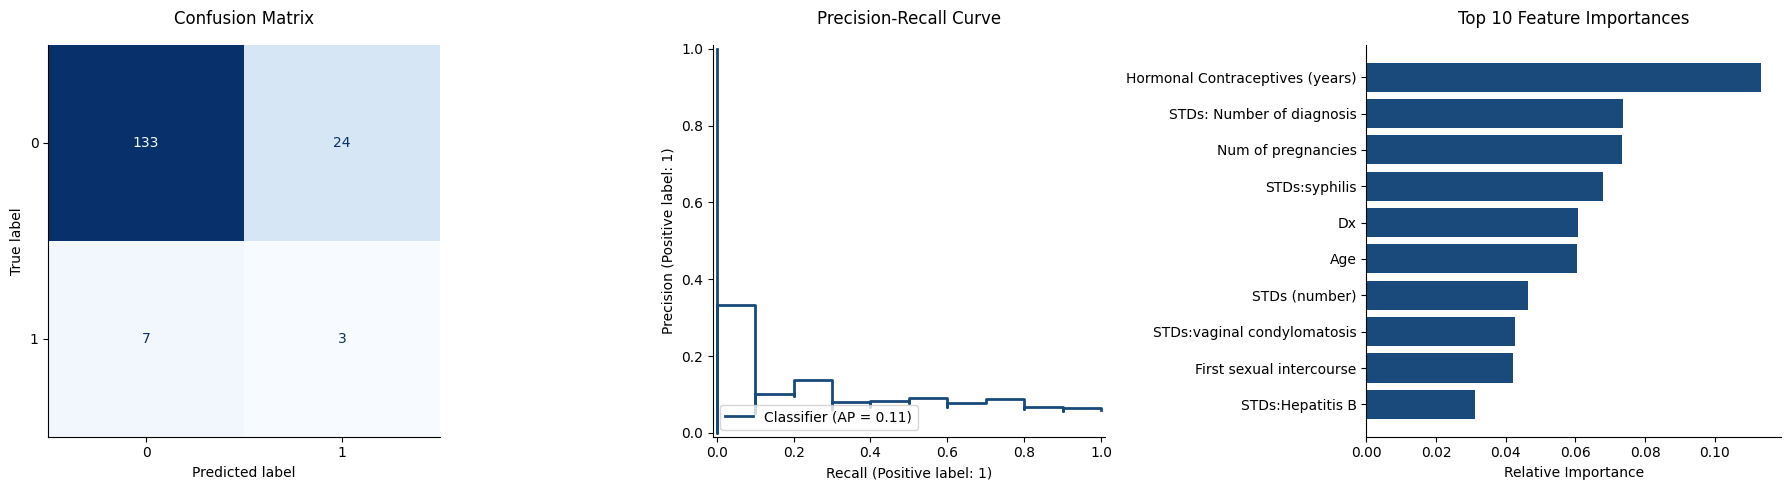

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay

# 5. Build the Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
# This shows exactly how many False Positives vs. True Positives you are getting
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    ax=axes[0], 
    cmap='Blues', 
    colorbar=False
)
axes[0].set_title('Confusion Matrix', pad=15)

# Plot B: Precision-Recall Curve
# This visualizes how your precision changes if you adjust the probability threshold
PrecisionRecallDisplay.from_predictions(
    y_test, 
    y_pred_proba, 
    ax=axes[1], 
    color='#1A4A7B',
    linewidth=2
)
axes[1].set_title('Precision-Recall Curve', pad=15)

# Plot C: Top 10 Feature Importances
# This reveals which columns the model relies on most heavily
importances = optimized_rf.feature_importances_

# Safely extract column names if X_train is a DataFrame
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns
else:
    feature_names = [f"Feature {i}" for i in range(X_train.shape[1])]

# Get indices of the top 10 most important features
top_10_indices = np.argsort(importances)[::-1][:10]
top_10_importances = importances[top_10_indices]
top_10_names = [feature_names[i] for i in top_10_indices]

# Create a horizontal bar chart (reversing order so the highest is at the top)
axes[2].barh(range(10), top_10_importances[::-1], align='center', color='#1A4A7B')
axes[2].set_yticks(range(10))
axes[2].set_yticklabels(top_10_names[::-1])
axes[2].set_title('Top 10 Feature Importances', pad=15)
axes[2].set_xlabel('Relative Importance')

# Clean up layout and display
# Removing top and right spines for a cleaner aesthetic
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

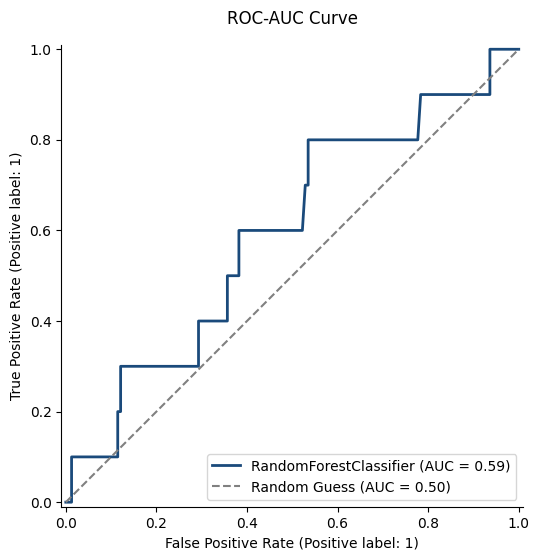

In [33]:
from sklearn.metrics import RocCurveDisplay

# 3. Plot the ROC curve (The simplest way)
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    optimized_rf, 
    X_test, 
    y_test, 
    ax=ax, 
    color='#1A4A7B',
    linewidth=2
)

# Add the 50/50 random guess line for context
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.50)')

plt.title('ROC-AUC Curve', pad=15)
plt.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

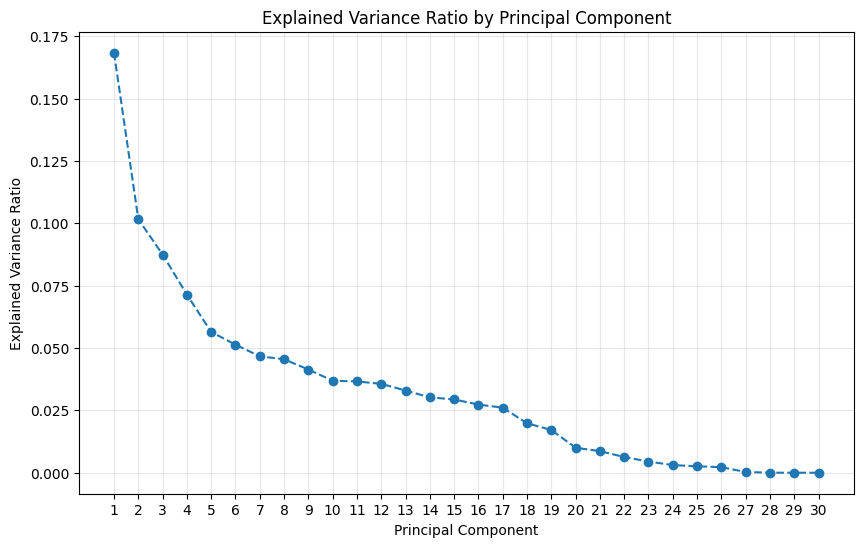

In [34]:
# Import necessary libraries for PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scale the X variable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Visualize explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('Explained Variance Ratio by Principal Component')
plt.xlabel('Principal Component')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.ylabel('Explained Variance Ratio')
plt.grid(alpha=0.3)
plt.show()


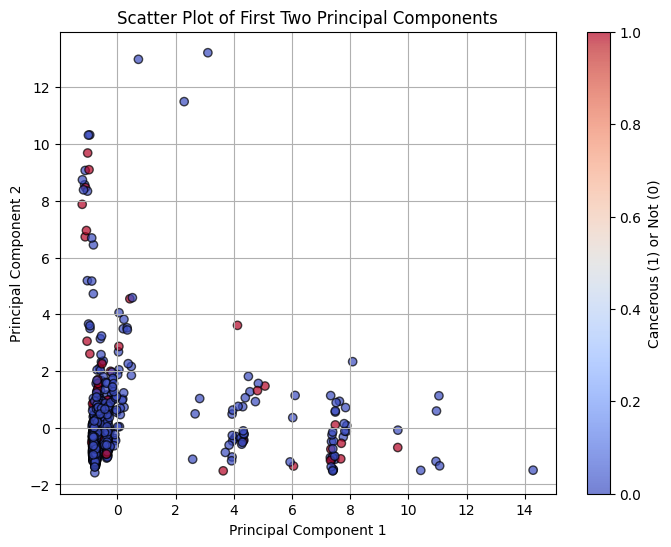

In [37]:
# Scatter plot of the first two principal components with color for cancerous cases
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolor='k')
plt.title('Scatter Plot of First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cancerous (1) or Not (0)')
plt.grid(True)
plt.show()

In [ ]:
# Create a heatmap of all features
plt.figure(figsize=(12, 8), facecolor='white')
heatmap = sns.heatmap(
    df.corr(), 
    annot=True,  # Add correlation values
    fmt='.2f',   # Format the annotation to 2 decimal places
    cmap='coolwarm',  # Use a diverging colormap for better contrast
    linewidths=0.5,  # Add gridlines between cells
    cbar_kws={'shrink': 0.8, 'aspect': 30}  # Adjust colorbar size
)

# Customize the title and axis labels
heatmap.set_title('Feature Correlation Heatmap', fontsize=16, pad=20)
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, horizontalalignment='right')
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 187-205 of the Storytelling With Data book as best you can. (Chapter Eight). You do not have to get the exact data values right, just the overall look and feel.

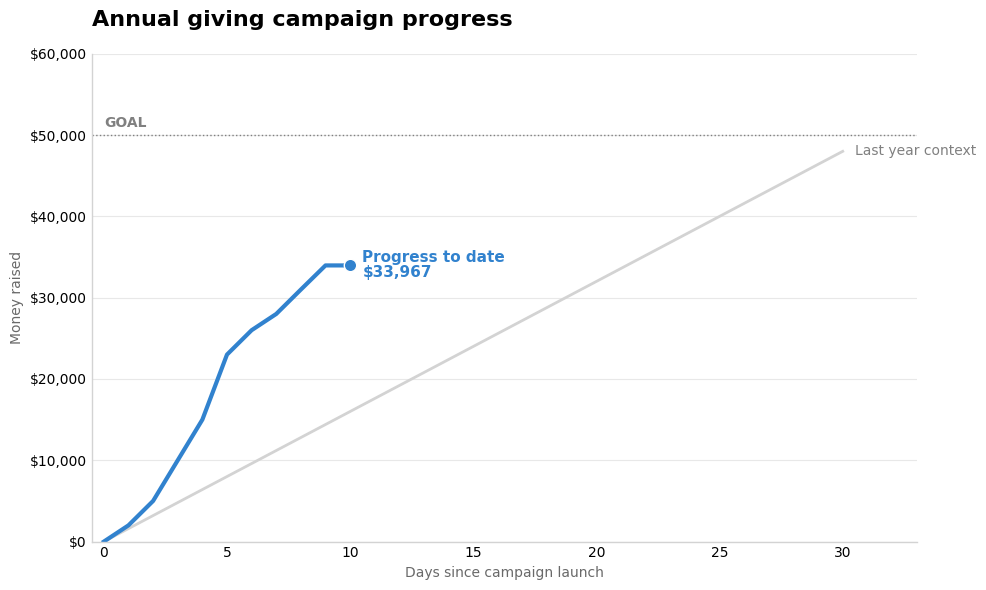

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Create dummy data to match the scenario
days = np.arange(0, 31)
goal_amount = 50000
previous_year_raised = np.linspace(0, 48000, 31) # Slightly below goal for comparison
current_progress_days = np.arange(0, 11)
current_progress_raised = np.array([
    0, 2000, 5000, 10000, 15000, 23000, 26000, 28000, 31000, 33967, 33967
])

# Define the exact data points for context
PROGRESS_TO_DATE_DAY = 10
PROGRESS_TO_DATE_AMOUNT = 33967

# Setup the plot
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Apply styling principles to declutter
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Keep only bottom and left spines and style them lightly
ax.spines['left'].set_color('lightgray')
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_color('lightgray')
ax.spines['bottom'].set_linewidth(1)

# Set grid only on y-axis, with light gray dashed lines
ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.5)

# Set titles and axis labels, matching the layout
plt.title('Annual giving campaign progress', loc='left', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Money raised', color='dimgray')
ax.set_xlabel('Days since campaign launch', color='dimgray')

# Format y-axis as currency
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))
ax.set_yticks([0, 10000, 20000, 30000, 40000, 50000, 60000])

# Format x-axis intervals
ax.set_xticks([0, 5, 10, 15, 20, 25, 30])
ax.tick_params(axis='both', which='both', length=0)

## 4. Plot the data

#  Plot previous year context (light gray)
plt.plot(days, previous_year_raised, color='lightgray', linewidth=2)

# Plot the Goal reference line (thin dotted gray)
plt.axhline(goal_amount, color='gray', linestyle=':', linewidth=1)

# Plot the progress to date (thick darker color, e.g., steel blue)
plt.plot(current_progress_days, current_progress_raised, color='#3182CE', linewidth=3)

# Add the specific marker and text for 'Progress to date'
plt.scatter(PROGRESS_TO_DATE_DAY, PROGRESS_TO_DATE_AMOUNT, s=80, color='#3182CE', edgecolor='white', zorder=5)

# Add Direct Labels (Replacing the need for a legend)
plt.text(30.5, 48000, 'Last year context', fontsize=10, color='gray', va='center')

# Goal reference line label
plt.text(0, goal_amount + 1000, 'GOAL', fontsize=10, color='gray', weight='bold')

# Progress to date labels: text and final amount
plt.text(PROGRESS_TO_DATE_DAY + 0.5, PROGRESS_TO_DATE_AMOUNT, 'Progress to date', fontsize=11, color='#3182CE', weight='bold', va='bottom', ha='left')
plt.text(PROGRESS_TO_DATE_DAY + 0.5, PROGRESS_TO_DATE_AMOUNT, '${:,}'.format(PROGRESS_TO_DATE_AMOUNT), fontsize=11, color='#3182CE', weight='bold', va='top', ha='left')

# Set limits
plt.ylim(0, 60000)
plt.xlim(-0.5, 33)

plt.tight_layout()
plt.show()